In [45]:
import pandas as pd
import numpy as np

In [46]:
df = pd.read_csv("../../data/car_fuel_efficiency.csv")


In [47]:
df.columns = df.columns.str.lower().str.replace(' ', '_')


In [48]:
df.head()

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
0,170,3.0,159.0,3413.433759,17.7,2003,Europe,Gasoline,All-wheel drive,0.0,13.231729
1,130,5.0,97.0,3149.664934,17.8,2007,USA,Gasoline,Front-wheel drive,0.0,13.688217
2,170,NaN,78.0,3079.038997,15.1,2018,Europe,Gasoline,Front-wheel drive,0.0,14.246341
3,220,4.0,NaN,2542.392402,20.2,2009,USA,Diesel,All-wheel drive,2.0,16.912736
4,210,1.0,140.0,3460.870990,14.4,2009,Europe,Gasoline,All-wheel drive,2.0,12.488369


In [49]:
df = df[['engine_displacement','horsepower','vehicle_weight','model_year','fuel_efficiency_mpg']]

In [50]:
import matplotlib.pyplot as plt 
import seaborn as sns
%matplotlib inline


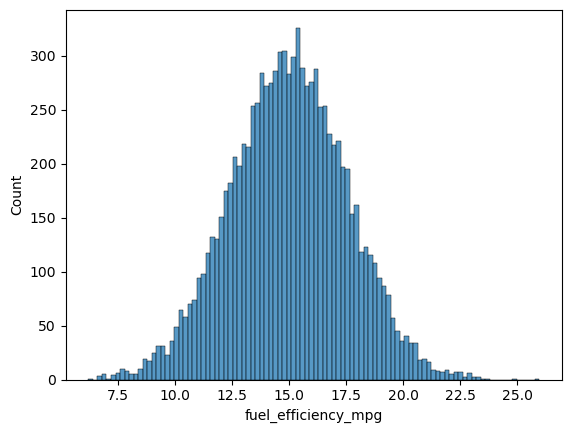

In [51]:
sns.histplot(df.fuel_efficiency_mpg, bins = 100)
plt.show()

In [52]:
df.isnull().sum()

engine_displacement      0
horsepower             708
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

In [53]:
df.horsepower.median()

149.0

In [54]:
n = len(df)

n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

In [55]:
idx = np.arange(n)
np.random.seed(42)
np.random.shuffle(idx)
df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train+n_val]]
df_test = df.iloc[idx[n_train+n_val:]]

In [56]:
y_train = df_train.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values

In [57]:
del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

In [58]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

In [59]:
def rmse(y, y_pred):
    se = (y - y_pred) ** 2
    mse = se.mean()
    return np.sqrt(mse)

In [60]:
def prepare_X_zeros(df):
    df = df.copy()    
    X = df.fillna(0).values
    return X

In [61]:
X_train_zeros = prepare_X_zeros(df_train)
w0, w = train_linear_regression(X_train_zeros, y_train)
X_val_zeros = prepare_X_zeros(df_val)
y_pred = w0 + X_val_zeros.dot(w)
score = round(rmse(y_val, y_pred), 2)
print (score)

0.52


In [62]:
def prepare_X_mean(df):
    df = df.copy()    
    mean = df.horsepower.mean()
    X = df.fillna(mean).values
    return X

In [63]:
X_train_mean = prepare_X_mean(df_train)
w0, w = train_linear_regression(X_train_mean, y_train)
X_val_mean = prepare_X_mean(df_val)
y_pred = w0 + X_val_mean.dot(w)
score = round(rmse(y_val, y_pred), 2)
print(score)

0.46


In [64]:
def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

In [69]:
for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    X_train_zeros = prepare_X_zeros(df_train)
    w0, w = train_linear_regression_reg(X_train_zeros, y_train, r=r)
    X_val_zeros = prepare_X_zeros(df_val)
    y_pred = w0 + X_val_zeros.dot(w)
    score = round(rmse(y_val, y_pred), 2)
    print(r, score)

0 0.51
0.01 0.51
0.1 0.52
1 0.52
5 0.52
10 0.52
100 0.52


In [73]:
scores = []
for seed in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]:
    idx = np.arange(n)
    np.random.seed(seed)
    np.random.shuffle(idx)
    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[idx[n_train:n_train+n_val]]
    df_test = df.iloc[idx[n_train+n_val:]]
    y_train = df_train.fuel_efficiency_mpg.values
    y_val = df_val.fuel_efficiency_mpg.values
    y_test = df_test.fuel_efficiency_mpg.values
    del df_train['fuel_efficiency_mpg']
    del df_val['fuel_efficiency_mpg']
    del df_test['fuel_efficiency_mpg']
    X_train = prepare_X_zeros(df_train)
    w0, w = train_linear_regression(X_train, y_train)
    X_val = prepare_X_zeros(df_val)
    y_pred = w0 + X_val.dot(w)
    score = rmse(y_val, y_pred)
    print(seed, score)
    scores.append(score)
print(round(np.std(scores), 3))


0 0.5206531296263988
1 0.5213388912862129
2 0.5228069974646676
3 0.5159516741272678
4 0.5109129460100481
5 0.5283406460150374
6 0.5313910658199212
7 0.5090670387337807
8 0.5147399129384682
9 0.5131865908366466
0.007


In [74]:
idx = np.arange(n)
np.random.seed(9)
np.random.shuffle(idx)
df_full_train = df.iloc[idx[:n_train+n_val]]
df_test = df.iloc[idx[n_train+n_val:]]
y_full_train = df_full_train.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values
del df_full_train['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

X_full_train = prepare_X_zeros(df_full_train)
w0, w = train_linear_regression_reg(X_full_train, y_full_train, r=0.001)
X_test = prepare_X_zeros(df_test)
y_pred = w0 + X_test.dot(w)
score = rmse(y_test, y_pred)
print (score)

0.5156261299162689
